In [1]:
import numpy as np
np.set_printoptions(threshold = np.inf)
import re
import openpnm as op
import heapq as hq
import matplotlib.pyplot as plt
from collections import deque
from tqdm.auto import tqdm
import scipy.sparse as sprs
from scipy.sparse import csgraph
from scipy.sparse.csgraph import connected_components
from openpnm._skgraph.simulations import bond_percolation, site_percolation
import os
current_directory = os.getcwd()
print(current_directory)

/home/gladys/Documents/Jupyter_projects/NewOpenPNM/Report_2024_final


In [2]:
import warnings
from pathlib import Path

In [3]:
ws=op.Workspace()
ws.clear()
proj = ws.new_project()

In [4]:
path = './Sandstone_Berea/'
file_name = 'Berea'
project = op.io.network_from_statoil(path,file_name)
pn = project.network

In [5]:
pn['pore.diameter'] = pn['pore.radius']*2
pn['throat.diameter'] = pn['throat.radius']*2
pn['pore.left'] = pn['pore.inlets']
pn['pore.right'] = pn['pore.outlets']

In [6]:
del pn['pore.inlets']
del pn['pore.outlets']
del pn['pore.radius']
del pn['throat.radius']
del pn['pore.clay_volume']
del pn['throat.clay_volume']

In [7]:
# Form the 2D NumPy array with shape (Nt, 3)
pn['throat.conduit_lengths'] = np.vstack([
    pn['throat.conduit_lengths.pore1'],
    pn['throat.conduit_lengths.throat'],
    pn['throat.conduit_lengths.pore2']
]).T

In [8]:
# Check PNM health & Trim
pn.add_model(propname='pore.cluster_number',
             model=op.models.network.cluster_number)
pn.add_model(propname='pore.cluster_size',
             model=op.models.network.cluster_size)
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x7a8b908d3110>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                12098 / 12098
  3  throat.shape_factor                                         12098 / 12098
  4  throat.total_length                                         12098 / 12098
  5  throat.length                                               12098 / 12098
  6  throat.conduit_lengths.throat                               12098 / 12098
  7  throat.volume                                               12098 / 12098
  8  throat.conduit_lengths.pore1                                12098 / 12098
  9  throat.conduit_lengths.pore2                                12098 / 12098
 

In [9]:
#print(pn['pore.cluster_number'])  
#print(pn['pore.cluster_size']) # it is from here that it comes the number 6004 
                               #you have to see the    

In [10]:
Ps = pn['pore.cluster_size']< 6004
op.topotools.trim(network=pn, pores=Ps)

In [11]:
geo = op.models.collections.geometry.spheres_and_cylinders
pn.add_model_collection(geo)
print(pn)


══════════════════════════════════════════════════════════════════════════════
net : <openpnm.network.Network at 0x7a8b908d3110>
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  #  Properties                                                   Valid Values
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
  2  throat.conns                                                12067 / 12067
  3  throat.shape_factor                                         12067 / 12067
  4  throat.total_length                                         12067 / 12067
  5  throat.length                                               12067 / 12067
  6  throat.conduit_lengths.throat                               12067 / 12067
  7  throat.volume                                               12067 / 12067
  8  throat.conduit_lengths.pore1                                12067 / 12067
  9  throat.conduit_lengths.pore2                                12067 / 12067
 

In [12]:
#print('Number of pores before trimming: ', pn.Np)
net_health= op.utils.check_network_health(network=pn)
print(net_health)
net_health_merged = np.union1d(net_health['isolated_pores'],net_health['disconnected_pores'])
op.topotools.trim(network= pn,pores=net_health_merged)
#print( op.utils.check_network_health(network=pn))

――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
Key                                 Value
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――
headless_throats                    []
looped_throats                      []
isolated_pores                      []
disconnected_pores                  []
duplicate_throats                   []
bidirectional_throats               []
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――


In [13]:
# bound_frac = 0.05
# Lx = max(pn['pore.coords'][:,0])-min(pn['pore.coords'][:,0])
# pn['pore.inlets'] = pn['pore.coords'][:,0]<=bound_frac*Lx
# pn['pore.outlets'] = pn['pore.coords'][:,0]>=(1-bound_frac)*Lx
# Inlets = np.where(pn['pore.inlets'])
# Outlets = np.where(pn['pore.outlets'])
# print(np.size(Inlets))
# print(np.size(Outlets))

In [14]:
flow_in = pn.pores('left')
flow_out = pn.pores('right')

In [15]:
incidence_m = pn.network.create_incidence_matrix(fmt='csr')

# Set Phases Oil-Water

In [16]:
oil = op.phase.Phase(network=pn,name='oil')
oil['pore.surface_tension'] = 0.030
oil['pore.contact_angle'] = 110
oil['pore.viscosity'] = 1.39e-3
oil['throat.viscosity'] = 1.39e-3
oil['pore.density'] = 900
oil['throat.density'] = 900
oil['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
oil['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
model = op.models.physics.capillary_pressure.washburn
oil.add_model(propname='throat.entry_pressure',
               model = model)
model1 = op.models.physics.hydraulic_conductance.valvatne_blunt
oil.add_model(propname='throat.hydraulic_conductance',
               model=model1) 
#oil.add_model_collection(op.models.collections.physics.basic)
oil.regenerate_models()

In [17]:
water = op.phase.Phase(network=pn,name='water')
water['pore.surface_tension'] = 0.030
water['pore.contact_angle'] = 70
water['pore.viscosity'] = 1.05e-3
water['throat.viscosity'] = 1.05e-3
water['pore.density'] = 996.95
water['throat.density'] = 996.95
water['pore.occupancy'] = np.zeros(pn.Np, dtype=bool)
water['throat.occupancy'] = np.zeros(pn.Nt, dtype=bool)
water.add_model(propname='throat.entry_pressure',
                model = model)
water.add_model(propname='throat.hydraulic_conductance',
                model=model1) 
#water.add_model_collection(op.models.collections.physics.basic)
water.regenerate_models()

In [18]:
BD_flow_oil = op.algorithms.StokesFlow(network=pn, phase=oil)
BD_flow_oil.set_value_BC(pores=flow_in, values=1)
BD_flow_oil.set_value_BC(pores=flow_out, values=0)
BD_flow_oil.run()
Inlet_flow_BD_oil = np.absolute(BD_flow_oil.rate(pores=flow_in))
# print(Inlet_flow_BD_oil)
# print(BD_flow_oil['pore.pressure'][Inlets])
# print(BD_flow_oil.rate(pores=Inlets, mode='single'))
# print(np.max(oil['throat.hydraulic_conductance']))

In [19]:
BD_flow_water = op.algorithms.StokesFlow(network=pn, phase=water)
BD_flow_water.set_value_BC(pores=flow_in, values=1)
BD_flow_water.set_value_BC(pores=flow_out, values=0)
BD_flow_water.run()
Inlet_flow_BD_water = np.absolute(BD_flow_water.rate(pores=flow_in))
# print(Inlet_flow_BD_water)
# print(BD_flow_water['pore.pressure'][Inlets])
# print(BD_flow_water.rate(pores=Inlets, mode='single'))
# print(np.max(water['throat.hydraulic_conductance']))

In [20]:
ip = op.algorithms.InvasionPercolation(network=pn, phase=oil)
ip.set_inlet_BC(pores=flow_in)
ip.run()

In [21]:
ip1 = op.algorithms.InvasionPercolation(network=pn,phase=oil)
ip1.set_inlet_BC(pores=flow_in)
ip1.set_outlet_BC(pores=flow_out)
ip1.run()
ip1.apply_trapping()

In [22]:
#print(ip['throat.invasion_sequence'])

In [23]:
#print(ip['pore.invasion_sequence'])

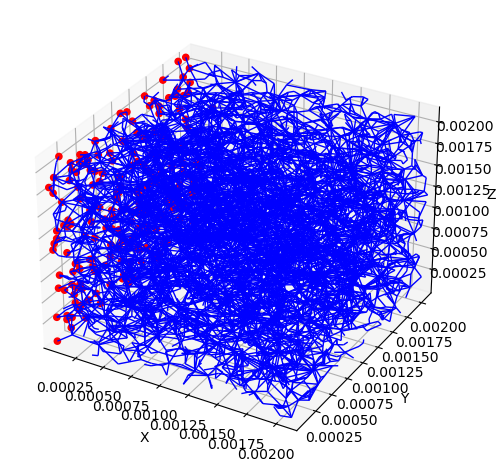

In [24]:
inv_pattern = ip['throat.invasion_sequence']<=150000
ax = op.visualization.plot_coordinates(network=pn, pores=flow_in, c='r', s=20)
ax = op.visualization.plot_connections(network=pn, throats=inv_pattern, ax=ax)

In [25]:
#print(ip1['throat.invasion_sequence'])

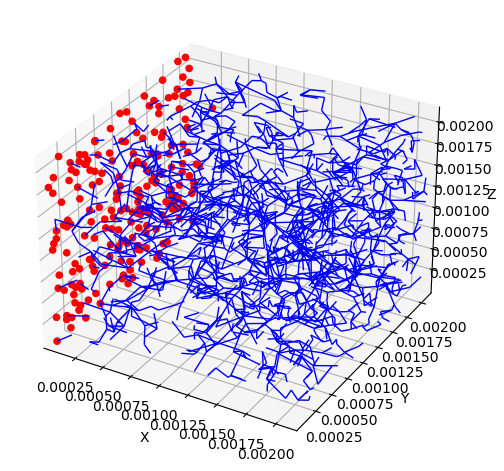

In [26]:
inv_pattern = ip1['throat.invasion_sequence']<=150000
ax = op.visualization.plot_coordinates(network=pn, pores=flow_in, c='r', s=20)
ax = op.visualization.plot_connections(network=pn, throats=inv_pattern, ax=ax)

# Relative Permeability 

In [27]:
def sat_occ_update(network, nwp, wp, ip, i):
    r"""
        Calculates the saturation of each phase using the invasion
        sequence from either invasion percolation.
        Parameters
        ----------
        network: network
        nwp : phase
            non-wetting phase
        wp : phase
            wetting phase
        ip : IP
            invasion percolation (ran before calling this function)
        i: int
            The invasion_sequence limit for masking pores/throats that
            have already been invaded within this limit range. The
            saturation is found by adding the volume of pores and thorats
            that meet this sequence limit divided by the bulk volume.
    """
    # Create masks for invaded pore/throats
    pore_mask = ip['pore.invasion_sequence'] < i
    throat_mask = ip['throat.invasion_sequence'] <i 

    # Calculates volumes for wetting phase (non-invaded volumes)
    wp_sat_p = np.sum(network['pore.volume'][~pore_mask])
    wp_sat_t = np.sum(network['throat.volume'][~throat_mask])
    wp_sat = wp_sat_p + wp_sat_t
    bulk = network['pore.volume'].sum() + network['throat.volume'].sum()

    # Calculateas the Saturation of the weatting phase
    sat = wp_sat/bulk

    # Update the phase occupancy
    nwp['pore.occupancy'] = pore_mask
    nwp['throat.occupancy'] = throat_mask
    wp['throat.occupancy'] = ~throat_mask
    wp['pore.occupancy'] = ~pore_mask
    # print('oil occupancy \n',nwp['pore.occupancy'])
    # print('water occupancy \n',wp['pore.occupancy'])
    return sat

In [28]:
def Rate_calc(network, phase, inlet, outlet, conductance):
    """
    Simulates stokes flow given the hydraulic conductance keyword 
    and returns the rate of inlet fluid flow.
    
    Parameters
    ----------
    network : network
    phase : phase
    inlet : array
        inlet pores
    outlet : array
        outlet pores
    conductance : str
        name of conductance model to use
    """
    phase.regenerate_models()
    St_p = op.algorithms.StokesFlow(network=network, phase=phase)
    St_p.settings._update({'conductance' : conductance})
    St_p.set_value_BC(pores=inlet, values=1)
    St_p.set_value_BC(pores=outlet, values=0)
    St_p.run()
    val = np.abs(St_p.rate(pores=inlet, mode='group'))
    phase.update(St_p.soln)
    return val

In [29]:
# model_mp = op.models.physics.h
model_mp_cond = op.models.physics.multiphase.conduit_conductance
# oil.add_model(model=model_mp_cond, propname='throat.hydraulic_conductance',
#               throat_conductance='throat.hydraulic_conductance', mode='loose', regen_mode='deferred')
oil.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')
water.add_model(model=model_mp_cond, propname='throat.conduit_hydraulic_conductance',
              throat_conductance='throat.hydraulic_conductance', mode='medium', regen_mode='deferred')

In [30]:
# upper_lim = 100000
# lower_lim = 10
# # print(hi,low)
# Sat_points = np.round(np.logspace(np.log10(upper_lim),np.log10(lower_lim), 500)[::-1])
# print(Sat_points)
# start = 0
# stop = 50000
# step = 100
# Swp = []
# relperm_nwp = []
# relperm_wp = []

In [31]:
# for i in range(start, stop, step): #Sat_points:
#     oil.regenerate_models()
#     water.regenerate_models()
#     sat = sat_occ_update(network=pn, nwp=oil, wp=water, ip=ip1, i=i) 
#     Swp.append(sat)
#     Rate_enwp = Rate_calc(pn, oil, Inlets, Outlets, 
#                           conductance = 'throat.conduit_hydraulic_conductance')
#     Rate_ewp = Rate_calc(pn, water, Inlets, Outlets, 
#                          conductance = 'throat.conduit_hydraulic_conductance')
#     relperm_nwp.append(Rate_enwp/Inlet_flow_BD_oil)
#     relperm_wp.append(Rate_ewp/Inlet_flow_BD_water)

In [32]:
# plt.figure(figsize=[6,5])
# plt.plot(Swp, relperm_nwp, marker='*', markersize=2, label='Kr_nwp')
# plt.plot(Swp, relperm_wp, marker='o',markersize=2,label='Kr_wp')
# plt.xlabel('Swp')
# plt.ylabel('Kr')
# plt.xlim(-0.05,1.05)
# plt.ylim(-0.05,1.05)
# plt.title('Relative Permeability in x direction')
# plt.legend()
# plt.savefig(f"3D_25x25x25/Krel_Drain_25x25.png")
# plt.close()

In [33]:
# Without Trapping

In [41]:
start = 0
stop = 50000
step = 100
Swp = []
relperm_nwp = []
relperm_wp = []

In [42]:
for i in range(start, stop, step): #Sat_points:
    oil.regenerate_models()
    water.regenerate_models()
    sat = sat_occ_update(network=pn, nwp=oil, wp=water, ip=ip, i=i) 
    Swp.append(sat)
    Rate_enwp = Rate_calc(pn, oil,flow_in, flow_out, 
                          conductance = 'throat.conduit_hydraulic_conductance')
    Rate_ewp = Rate_calc(pn, water,flow_in, flow_out,
                         conductance = 'throat.conduit_hydraulic_conductance')
    relperm_nwp.append(Rate_enwp/Inlet_flow_BD_oil)
    relperm_wp.append(Rate_ewp/Inlet_flow_BD_water)

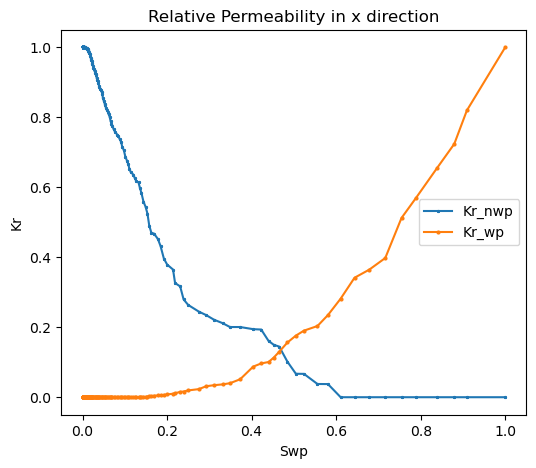

In [43]:
plt.figure(figsize=[6,5])
plt.plot(Swp, relperm_nwp, marker='*', markersize=2, label='Kr_nwp')
plt.plot(Swp, relperm_wp, marker='o',markersize=2,label='Kr_wp')
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.title('Relative Permeability in x direction')
plt.legend()

In [37]:
# With Trapping

In [38]:
start = 0
stop = 50000
step = 100
Swp1 = []
relperm_nwp1 = []
relperm_wp1 = []

In [39]:
for i in range(start, stop, step): #Sat_points:
    oil.regenerate_models()
    water.regenerate_models()
    sat = sat_occ_update(network=pn, nwp=oil, wp=water, ip=ip1, i=i) 
    Swp1.append(sat)
    Rate_enwp1 = Rate_calc(pn, oil,flow_in, flow_out, 
                          conductance = 'throat.conduit_hydraulic_conductance')
    Rate_ewp1 = Rate_calc(pn, water,flow_in, flow_out,
                         conductance = 'throat.conduit_hydraulic_conductance')
    relperm_nwp1.append(Rate_enwp1/Inlet_flow_BD_oil)
    relperm_wp1.append(Rate_ewp1/Inlet_flow_BD_water)

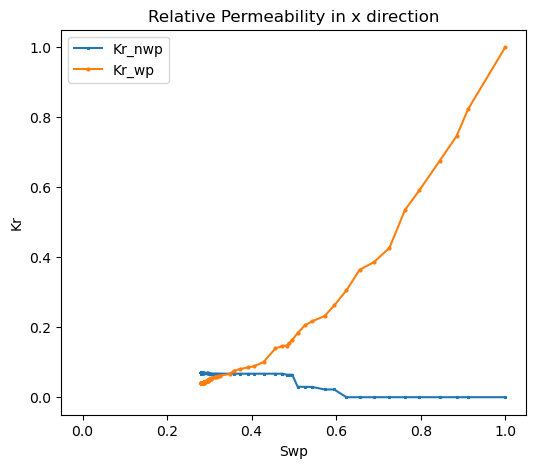

In [40]:
plt.figure(figsize=[6,5])
plt.plot(Swp1, relperm_nwp1, marker='*', markersize=2, label='Kr_nwp')
plt.plot(Swp1, relperm_wp1, marker='o',markersize=2,label='Kr_wp')
plt.xlabel('Swp')
plt.ylabel('Kr')
plt.xlim(-0.05,1.05)
plt.ylim(-0.05,1.05)
plt.title('Relative Permeability in x direction')
plt.legend()